In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import kagglehub

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
path = kagglehub.dataset_download("navoneel/brain-mri-images-for-brain-tumor-detection")

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(path, transform=transform)

print("Classes:", dataset.classes)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset, [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

num_classes = len(dataset.classes)

Using Colab cache for faster access to the 'brain-mri-images-for-brain-tumor-detection' dataset.
Classes: ['brain_tumor_dataset', 'no', 'yes']


In [ ]:
# MODEL
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3,16,3,padding=1)
        self.conv2 = nn.Conv2d(16,32,3,padding=1)

        self.pool = nn.MaxPool2d(2,2)
        self.relu = nn.ReLU()

        # Added Global Average Pooling to prepare for CAM
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Final linear layer now maps directly from the number of channels of conv2
        self.fc = nn.Linear(32, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))

        self.feature_maps = x # Store feature maps from the last conv layer

        # Apply global average pooling and flatten for the final classifier
        x = self.global_avg_pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x

model = CNN().to(device)

In [ ]:
print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))


Trainable params: 12850659


In [ ]:
# LOSS + OPTIMIZER
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# TRAINING
for epoch in range(5):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch", epoch+1, "done")

Epoch 1 done
Epoch 2 done
Epoch 3 done
Epoch 4 done
Epoch 5 done


In [ ]:
# TESTING
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, pred = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (pred == labels).sum().item()

print("Test Accuracy:", 100 * correct / total)

Test Accuracy: 30.392156862745097


In [ ]:
# CAM (basic version exactly like notebook style)
def generate_cam(model, image, class_idx):
    model.eval() # Set model to evaluation mode for consistent behavior

    # Forward pass to get feature maps and output
    _ = model(image)

    # Weights from the final classification layer for the target class
    weights = model.fc.weight[class_idx]

    # Squeeze batch dimension from feature maps
    feature_maps = model.feature_maps.squeeze(0)

    # Initialize CAM with the spatial dimensions of feature maps
    cam = torch.zeros(feature_maps.shape[1:], device=image.device)

    # Create CAM by summing weighted feature maps
    for i, w in enumerate(weights):
        cam += w * feature_maps[i]

    # Normalize CAM
    cam = cam.detach().cpu().numpy()
    cam = np.maximum(cam, 0)

    if cam.max() != 0:
        cam = cam / cam.max()

    return cam

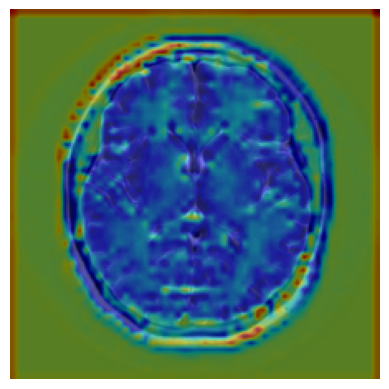

In [ ]:
# VISUALIZATION
image, label = dataset[0]
input_img = image.unsqueeze(0).to(device)

output = model(input_img)
class_idx = output.argmax().item()

cam = generate_cam(model, input_img, class_idx)

img = image.permute(1,2,0).numpy()

cam = cv2.resize(cam, (224,224))

plt.imshow(img)
plt.imshow(cam, cmap='jet', alpha=0.5)
plt.axis('off')
plt.show()